# Diffusion-reaction equation with time-dependent Dirichlet boundary conditions

$$
\mathbb{S}_u
\begin{cases}
\Omega = [0, L_x] \\
u_0 = 0 \\
u_{\text{D}}(x=0, t)=\epsilon\sin(\omega t) \\
u_{\text{D}}(x=L_x)=0 \\
\mathsf{D}=\mathsf{I} \\
R=-1 \\
J=1 \\
\end{cases}
$$

In [ ]:
import numpy as np
from lucifex.mesh import interval_mesh
from lucifex.fdm import (
    BE, finite_difference_order,
    FiniteDifference, FunctionSeries, ConstantSeries,
)
from lucifex.sim import run, Simulation
from lucifex.fem import Constant
from lucifex.solver import ibvp, evaluation, BoundaryConditions
from lucifex.plt import plot_line, create_animation, save_figure, display_animation
from lucifex.pde.diffusion import diffusion_reaction

def sine_wave(t, eps, omega):
    return eps * np.sin(omega * float(t))

def create_simulation(
    Lx: float,
    Nx: int,
    dt: float,
    eps: float,
    omega: float,
    D_diff: FiniteDifference,
    D_reac: FiniteDifference,
) -> Simulation:
    order = finite_difference_order(D_diff, D_reac)
    store = 1
    mesh = interval_mesh(Lx, Nx)
    t = ConstantSeries(mesh, name='t', ics=0.0)
    dt = Constant(mesh, dt, name='dt')  
    u = FunctionSeries((mesh, 'P', 1), 'u', order, store, ics=0.0)
    uD = ConstantSeries(mesh, order=order, store=store, ics=sine_wave(0.0, eps, omega), name='uD')
    uD_solver = evaluation(uD, sine_wave, future=True)(t[0] + dt, eps, omega)
    bcs = BoundaryConditions(
        ('dirichlet', lambda x: x[0], uD[1]),
        ('dirichlet', lambda x: x[0] - Lx, 0.0),
    )
    d = Constant(mesh, 1.0, 'd')
    r = Constant(mesh, -1.0, 'r')
    j = Constant(mesh, 1.0, 'j')
    u_solver = ibvp(diffusion_reaction, bcs=bcs)(u, dt, d, r, j, D_diff, D_reac)
    return Simulation([uD_solver, u_solver], t, dt)


Lx = 1.0
Nx = 100
dt = 0.01
eps = 0.1
omega = 20
simulation = create_simulation(Lx, Nx, dt, eps, omega, BE, BE)
n_stop = 50
run(simulation, n_stop)

u = simulation['u']

In [ ]:
u_min = np.min([np.min(dofs) for dofs in u.dofs_series])
u_max = np.max([np.max(dofs) for dofs in u.dofs_series])

y_label_series = [f'$u(t={t:.2f})$' for t in u.time_series]
anim = create_animation(
    plot_line,
    y_lims=(u_min, u_max),
    x_label='$x$', 
)(u.series, y_label=y_label_series)
anim_path = save_figure('u(x,t)', return_path=True)(anim)

display_animation(anim_path)

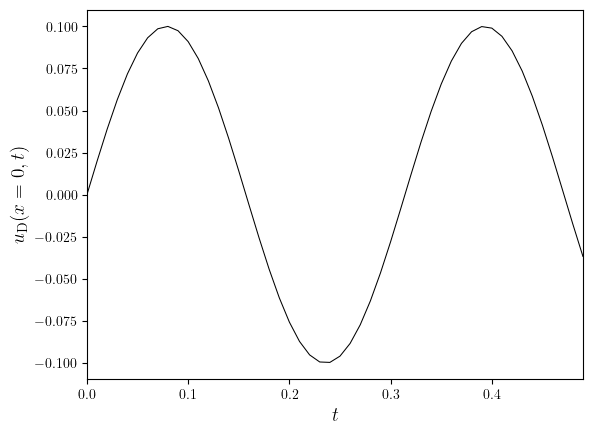

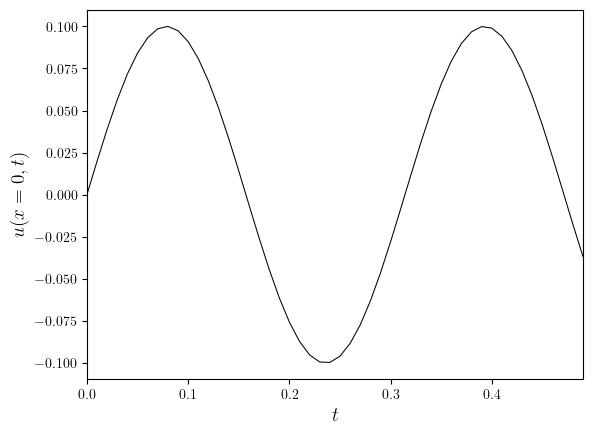

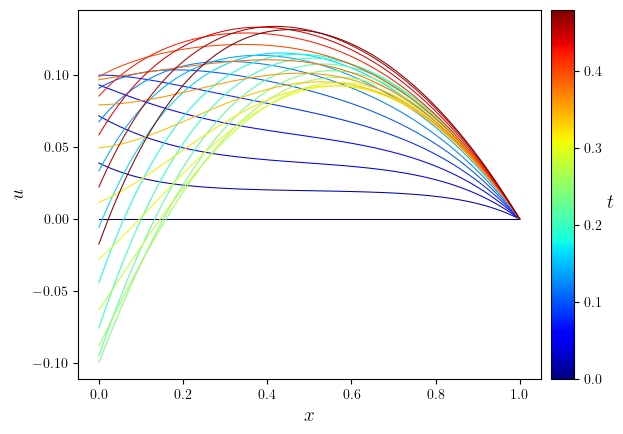

In [ ]:
slc = slice(0, None, 2)
legend_labels=(min(u.time_series[slc]), max(u.time_series[slc]))
fig, ax = plot_line(u.series[slc], legend_labels, '$t$', cyc='jet', x_label='$x$', y_label='$u$')
save_figure('u(x,t)', thumbnail=True)(fig)

uD = simulation['uD']
fig, ax = plot_line((uD.time_series, uD.value_series), x_label='$t$', y_label='$u_{\mathrm{D}}(x=0,t)$')
save_figure('uD(x=0,t)')(fig)

u = simulation['u']
u_x0 = [dofs[0] for dofs in u.dofs_series]
fig, ax = plot_line((u.time_series, u_x0), x_label='$t$', y_label='$u(x=0, t)$')
save_figure('u(x=0,t)')(fig)